In [296]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# import data visualization package
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jayasuhane/ibm-dataset/IBM-HR-Employee-Attrition.csv


In [297]:
# load dataset
df=pd.read_csv('/kaggle/input/datasets/jayasuhane/ibm-dataset/IBM-HR-Employee-Attrition.csv')
#df.head()
df.info()
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [298]:
# check data shape
df.shape

(1470, 35)

The output indicates that the DataFrame has 1,470 rows and 35 columns

In [299]:
#In [4]:
# check number of dupliacted data
print(f'Number of duplicated data: {df.duplicated().sum()}')

Number of duplicated data: 0


In [300]:
print("length of dataframe:",len(df))
print("Null values in data frame", df.isnull().sum())
# check missing values
df.isnull().sum() / len(df) * 100

length of dataframe: 1470
Null values in data frame Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany    

Age                         0.0
Attrition                   0.0
BusinessTravel              0.0
DailyRate                   0.0
Department                  0.0
DistanceFromHome            0.0
Education                   0.0
EducationField              0.0
EmployeeCount               0.0
EmployeeNumber              0.0
EnvironmentSatisfaction     0.0
Gender                      0.0
HourlyRate                  0.0
JobInvolvement              0.0
JobLevel                    0.0
JobRole                     0.0
JobSatisfaction             0.0
MaritalStatus               0.0
MonthlyIncome               0.0
MonthlyRate                 0.0
NumCompaniesWorked          0.0
Over18                      0.0
OverTime                    0.0
PercentSalaryHike           0.0
PerformanceRating           0.0
RelationshipSatisfaction    0.0
StandardHours               0.0
StockOptionLevel            0.0
TotalWorkingYears           0.0
TrainingTimesLastYear       0.0
WorkLifeBalance             0.0
YearsAtC

In [301]:
#In [6]:
# check data types
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

All columns have appropriate data types, ensuring that the data is correctly formatted
for analysis.

In [302]:
#In [7]:
# check data decribe
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Based on this summary, there are no apparent outliers in the dataset, as the values
fall within expected ranges.

In [303]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
print("q1",Q1)
print("q3",Q3)
IQR = Q3 - Q1
print("iqr",IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound",lower_bound)
print("Upper Bound",upper_bound)
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

print("Outliers",outliers)

q1 30.0
q3 43.0
iqr 13.0
Lower Bound 10.5
Upper Bound 62.5
Outliers Empty DataFrame
Columns: [Age, Attrition, BusinessTravel, DailyRate, Department, DistanceFromHome, Education, EducationField, EmployeeCount, EmployeeNumber, EnvironmentSatisfaction, Gender, HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction, MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked, Over18, OverTime, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StandardHours, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager]
Index: []

[0 rows x 35 columns]


Empty DataFrame
Columns: [...]
Index: []
✅ It means:

There are no values outside the calculated lower and upper bounds.

In simple words:

🚫 No extreme values detected
✅ Your data is within the normal range (based on IQR rule)
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
If no rows satisfy that condition, pandas returns an empty DataFrame.

That’s actually a good sign in many cases 👍

In [304]:
#Exploratory Data Analysis
#In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [305]:
# Attrition Rate
# Attrition rate: The attrition rate measures the percentage of employees who leave the
# company in a given period of time. It is usually calculated within a year and is
# expressed as a percentage of the total number of employees.
# In [9]:
df['Attrition'].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

1️⃣ df['Attrition']

This selects the Attrition column from the DataFrame.
2️⃣ .value_counts()

This counts how many times each value appears.

Example output:

No     1233
Yes     237

👉 Meaning:

1233 employees stayed

237 employees left
3️⃣ normalize=True

This converts the counts into proportions (percentages in decimal form).

Instead of raw numbers, you get:(1233/1470)*100 and (237/1470)*100
This means:

83.9% employees stayed

16.1% employees left
The output displays the proportion of employees with regard to attrition status in the
dataset. Let's visualize it!

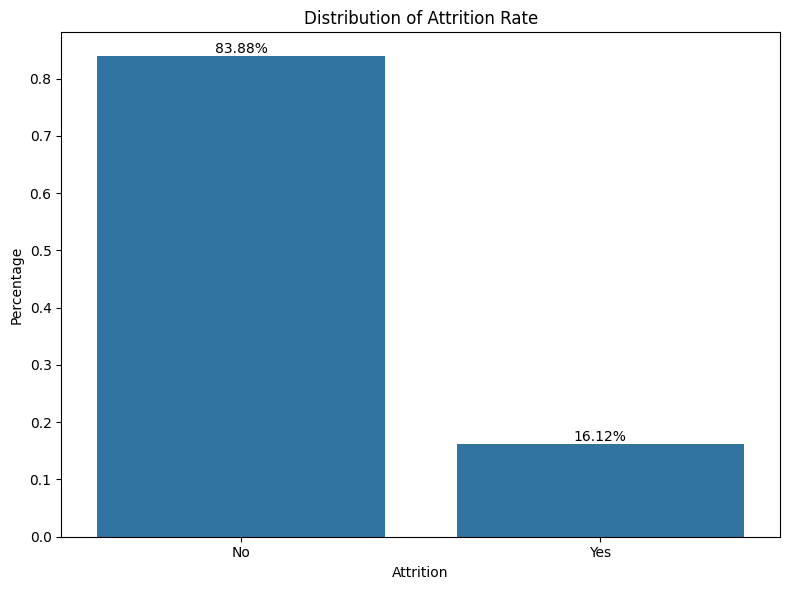

In [306]:
#In [10]:
attrition = df['Attrition'].value_counts(normalize=True)
plt.figure(figsize=(8,6))
ax = sns.barplot(x=attrition.index, y=attrition)
for p in ax.patches:
    ax.annotate(f'{p.get_height() * 100:.2f}%',(p.get_x() + p.get_width() / 2.,p.get_height()),ha='center', va='bottom')
plt.title('Distribution of Attrition Rate')
plt.xlabel('Attrition')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

Based on the analysis, the company's attrition rate is 16.12%. This means that about
16.12% of the employees decided to leave the company during the analyzed period.

🔹 1. Improve Compensation for Low Salary Employees

Since low-salary employees have 2x higher attrition:

Solutions:

Salary benchmarking with market rates

Performance-based bonuses

Structured annual increments

📌 Impact: Reduces financially motivated exits.

🔹 2. Reduce Overtime Pressure

If employees doing overtime leave more:

Solutions:

Hire additional staff in high-pressure departments

Automate repetitive tasks

Monitor workload distribution

📌 Impact: Reduces burnout-driven attrition.

🔹 3. Focus on Sales Department

Sales often has:

High targets

High stress

High turnover

Solutions:

Realistic target setting

Incentive restructuring

Recognition programs

Career progression into managerial roles

📌 Impact: Stabilizes high-risk department.

🔹 4. Career Growth for 5–7 Year Employees

Since average leaving tenure is 7 years:

Solutions:

Leadership training programs

Internal promotions

Role rotations

Skill development sponsorship

📌 Impact: Reduces mid-career exits.

🔹 5. Improve Work Environment & Engagement

Often attrition is emotional, not just financial.

Solutions:

Employee engagement surveys

Feedback mechanisms

Flexible work policies

Recognition culture



Find Average of Tenure
Average tenure: The average tenure measures the average number of years an
employee stays with the company before leaving. It can provide insight into workforce
stability and employee satisfaction within the organization.

In [307]:
#In [11]:
avg_tenure = df['YearsAtCompany'].mean()
print(f'Average years of employee to leave the company is :{avg_tenure} years')

Average years of employee to leave the company is :7.0081632653061225 years


The average tenure of employees before they decided to leave was 7.01 years. With
this average tenure, it can be concluded that many employees feel comfortable and
have been with the company for a long time.

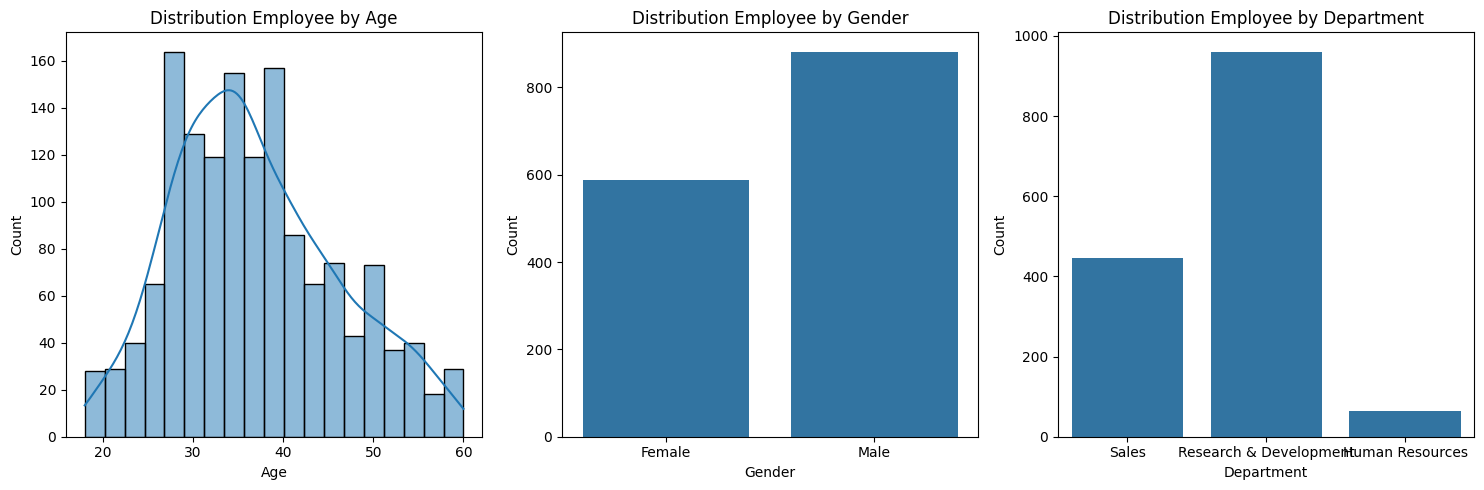

In [308]:
#Employee's Demographics
#In [12]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
sns.histplot(data=df, x='Age', kde=True, ax=axes[0])
axes[0].set_title('Distribution Employee by Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
plt.savefig("distribution Employee by age.png", dpi=300, bbox_inches='tight')

sns.countplot(data=df, x='Gender', ax=axes[1])
axes[1].set_title('Distribution Employee by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
plt.savefig("distribution Employee by gender.png", dpi=300, bbox_inches='tight')

sns.countplot(data=df, x='Department', ax=axes[2])
axes[2].set_title('Distribution Employee by Department')
axes[2].set_xlabel('Department')
axes[2].set_ylabel('Count')
plt.savefig("distribution Employee by department.png", dpi=300, bbox_inches='tight')
plt.tight_layout()

plt.show()

1️⃣ Distribution of Employees by Age

👉 This is a histogram showing how employees are spread across different age groups.

🔎 What we can observe:

Most employees are between 28 to 40 years old

The peak appears around 30–35 years

Very few employees are:

Below 22

Above 55

📌 Interpretation:

The company workforce is primarily mid-career professionals

It suggests a relatively young to middle-aged workforce

Hiring may focus more on experienced professionals rather than freshers

2️⃣ Distribution of Employees by Gender

👉 This bar chart shows total count of Male vs Female employees.

🔎 What we can observe:

Male employees are significantly higher than female employees

There is a noticeable gender imbalance

📌 Interpretation:

Workforce is male-dominated

Company may need diversity initiatives if aiming for gender balance
🏢 3️⃣ Department Distribution Insights
🔎 Observations:

Research & Development has the highest number of employees

Sales has moderate representation

Human Resources has very few employees

🎯 Insights:

Company is heavily focused on R&D → likely product/innovation-driven organization

HR department is very small relative to total workforce

Sales team size suggests moderate market expansion focus

🎯 Professional Insight Summary (You can use in PPT)

The workforce is primarily concentrated between 28–40 years, indicating a strong mid-career employee base. Additionally, the gender distribution reveals a male-dominated organization, suggesting potential opportunities to improve workforce diversity.

💡 If This is for HR Attrition Project

You can connect it like this:

Younger employees may have different attrition behavior

Gender imbalance could influence retention patterns

Age distribution can help segment attrition analysis

If you want, I can also help you:

Write slide content (ready-to-paste format)

Connect this to attrition analysis

Create business recommendations from this chart

You’re building strong analytical storytelling skills 👏

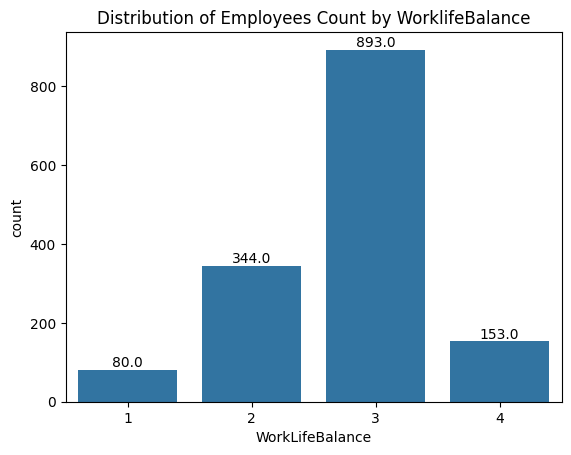

In [309]:
ax=sns.countplot(data=df, x='WorkLifeBalance')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.title('Distribution of Employees Count by WorklifeBalance')
plt.savefig("distribution Employee count by WorkLifeBalance.png", dpi=300, bbox_inches='tight')
plt.show()

📌 Strategic Interpretation

Although most employees report “Better” work-life balance, relatively few rate it as “Best,” indicating an opportunity to enhance flexible work policies and employee well-being initiatives to improve satisfaction further.

In [310]:
# correlation between WorkLifeBalance and Attrition
#This shows how many employees left in each WorkLifeBalance category.

pd.crosstab(df['WorkLifeBalance'], df['Attrition'])

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


In [311]:
#Calculate Attrition Percentage by WorkLifeBalance

#This is more powerful 👇

wlb_attrition = pd.crosstab(df['WorkLifeBalance'], df['Attrition'], normalize='index') * 100
wlb_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


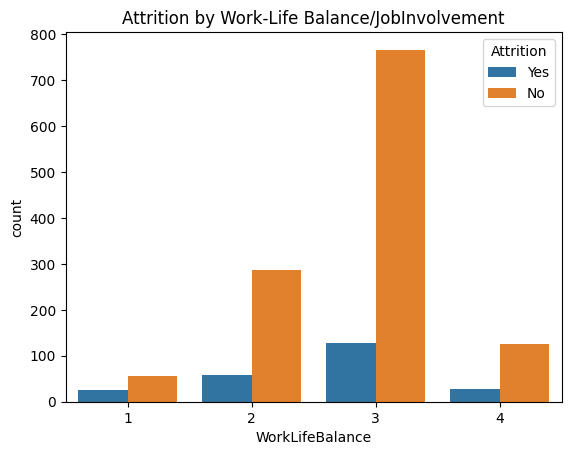

In [312]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition')
plt.title('Attrition by Work-Life Balance/JobInvolvement')
plt.show()

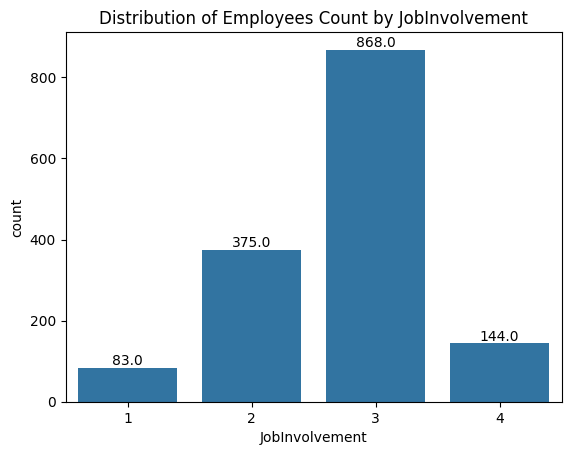

In [313]:
ax = sns.countplot(data=df, x='JobInvolvement')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribution of Employees Count by JobInvolvement')
plt.savefig("distribution Employee count by JobInvolvement.png", dpi=300, bbox_inches='tight')
plt.show()

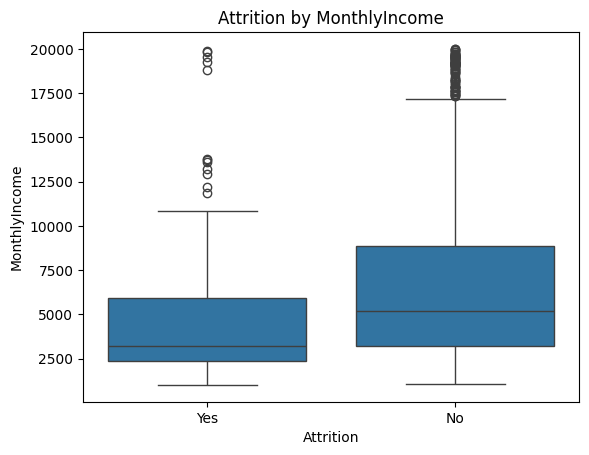

In [314]:
#Salary factor by MonthlyIncome
import seaborn as sns
import matplotlib.pyplot as plt

#sns.countplot(data=df, x='MonthlyIncome', hue='Attrition')
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Attrition by MonthlyIncome')
plt.savefig("Attrition by MonthlyIncomeBoxplot.png", dpi=300, bbox_inches='tight')
plt.show()

📊 What This Chart Shows

It compares Monthly Income distribution between:

Employees who left the company (Attrition = Yes)

Employees who stayed in the company (Attrition = No)

🔎 How to Read the Boxplot

For each Attrition category, the boxplot shows:

Median (middle line in the box) → Typical salary

Box (IQR – Interquartile Range) → Middle 50% of salaries

Whiskers → Spread of salaries

Dots (if any) → Outliers (very high or low incomes)

📈 What It Usually Indicates (IBM HR Dataset Case)

In most IBM HR Attrition datasets:

Employees with Attrition = Yes tend to have:

Lower median income

Smaller salary range

Employees with Attrition = No tend to have:

Higher median income

Wider salary distribution

💡 Interpretation for Your Project

If your plot shows lower median income for employees who left, it means:

💬 Employees with lower salaries are more likely to leave the company.

This strongly supports your earlier finding:

“Employees with low salary have 2x higher attrition rate”

That makes your analysis consistent and powerful for your conclusion section 👏

🎯 How You Can Write This in Your Report

You can say:

The boxplot analysis shows that employees who left the company had significantly lower median monthly income compared to those who stayed, indicating salary is a key factor influencing attrition.

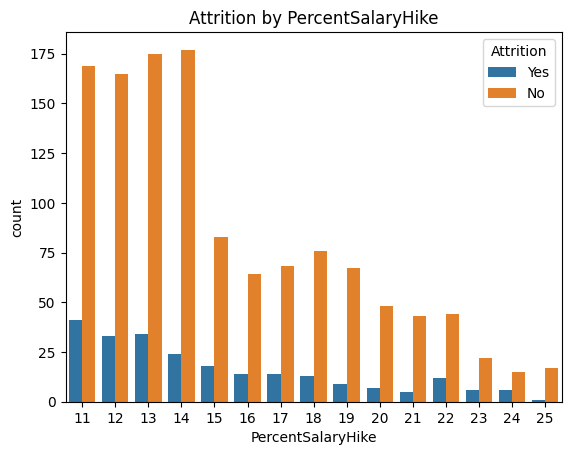

In [315]:
#Salary Factor by SalaryHike
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='PercentSalaryHike', hue='Attrition')
plt.title('Attrition by PercentSalaryHike')
plt.savefig("Attrition By PercentSalaryhike.png", dpi=300, bbox_inches='tight')
plt.show()

📊 What This Chart Shows

The chart shows Attrition (Yes/No) across different PercentSalaryHike values (11%–25%).

Blue bars → Employees who left (Attrition = Yes)

Orange bars → Employees who stayed (Attrition = No)

X-axis → Percentage salary hike

Y-axis → Employee count

🔎 Key Observations
1️⃣ Most Employees Receive 11%–14% Hike

You can see the highest employee counts around:

11%

12%

13%

14%

This suggests:
👉 Most increments fall in this range.

2️⃣ Attrition is Higher at Lower Salary Hikes

At 11–13% hike:

The number of employees leaving is comparatively higher.

As salary hike increases (18%–25%):

The number of employees leaving decreases significantly.

This suggests a pattern 👇

🎯 Main Insight

👉 Lower salary hikes are associated with higher attrition.

Employees receiving smaller increments are more likely to leave.

3️⃣ High Salary Hike = Lower Attrition

At 21%–25% hike:

Very few employees left.

This indicates:

Competitive increments improve retention.

📌 Strategic Interpretation

The data suggests that salary increment percentage plays a role in employee retention. Employees receiving lower percentage hikes show relatively higher attrition, whereas higher increments appear to reduce attrition risk.

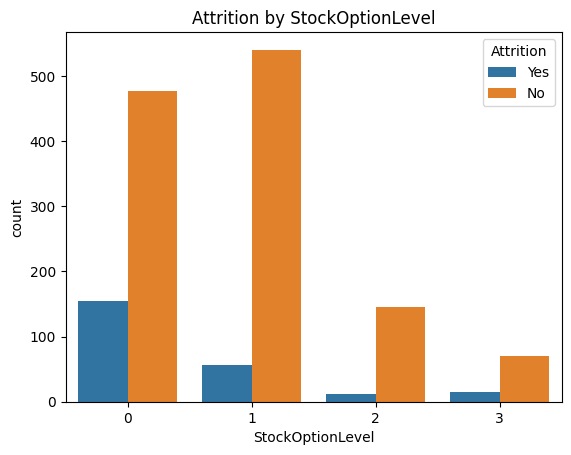

In [316]:
#benefit factors
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='StockOptionLevel', hue='Attrition')
plt.title('Attrition by StockOptionLevel')
plt.savefig("Attrition by StockOptionLevel.png", dpi=300, bbox_inches='tight')
plt.show()

📊 What This Chart Shows

This is a countplot, so it shows:

X-axis → StockOptionLevel (0, 1, 2, 3)

Bars → Number of employees

Colors (hue) → Attrition (Yes vs No)

So basically:

It shows how attrition varies across different stock option levels.

🔎 How to Interpret It

Look at each stock option level:

🔹 StockOptionLevel = 0

If you see:

Higher number of Attrition = Yes

Compared to other levels

👉 That means employees without stock options are more likely to leave.

🔹 StockOptionLevel = 1, 2, 3

If:

Attrition = Yes decreases as stock option level increases

Attrition = No bars are much higher

👉 That means:

Employees with better stock benefits tend to stay longer.

💡 What This Usually Means (IBM HR Dataset Pattern)

In most IBM HR Attrition analyses:

Employees with StockOptionLevel = 0 have highest attrition

Higher stock option levels show lower attrition

This suggests:

Stock options improve employee retention because they create long-term financial incentives.

🎯 Business Insight You Can Write

You can say:

The analysis shows that employees without stock options exhibit higher attrition. As stock option levels increase, attrition decreases, indicating that equity-based compensation plays a significant role in employee retention.